In [1]:
from scipy import stats

In [2]:
import numpy as np

In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("WineQT.csv")
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
df_clean = df[(z_scores < 3).all(axis=1)]
print(f"Outliers removed: {len(df) - len(df_clean)}")

Outliers removed: 102


In [5]:
stats_summary = df.groupby('quality').agg({
'alcohol': ['mean', 'std'],
'volatile acidity': ['mean', 'max'],
'sulphates': 'mean'
})
print(stats_summary)

           alcohol           volatile acidity       sulphates
              mean       std             mean   max      mean
quality                                                      
3         9.691667  0.886801         0.897500  1.58  0.550000
4        10.260606  1.026200         0.700000  1.09  0.637879
5         9.902277  0.752592         0.585280  1.33  0.613375
6        10.655339  1.054314         0.504957  1.04  0.676537
7        11.482634  0.980337         0.393671  0.84  0.743566
8        11.937500  1.185397         0.410000  0.85  0.766250


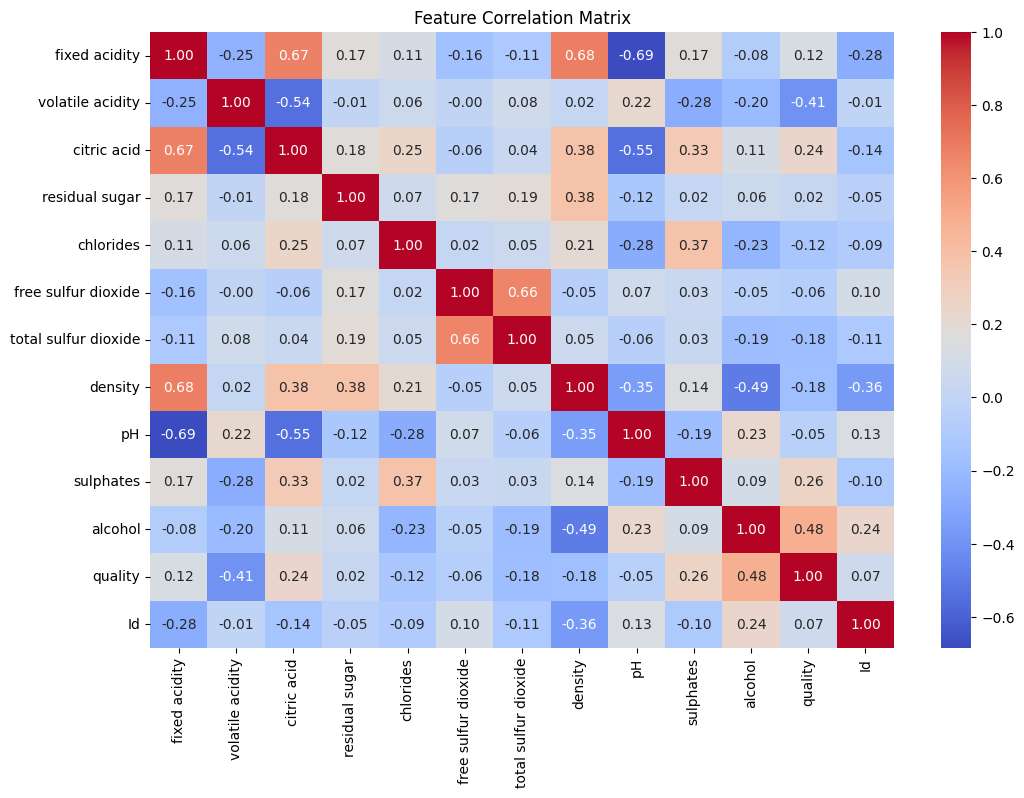

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

skewness:0.8633132317223615


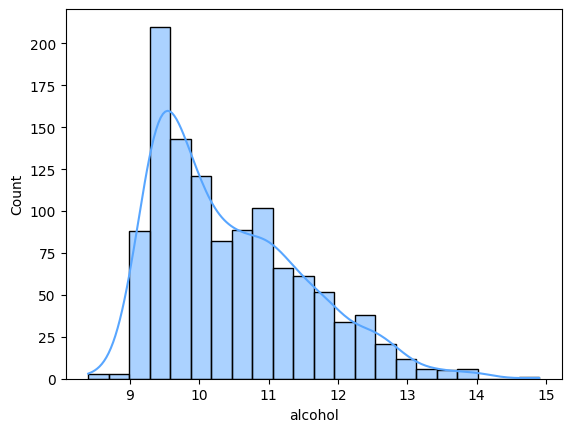

In [7]:
sns.histplot(df['alcohol'],kde=True,color='#58a6ff')
print(f"skewness:{df['alcohol'].skew()}")

C:\Users\Raja\AppData\Local\Temp\ipykernel_8836\2605521167.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='pH', data=df, palette='viridis')


Text(0.5, 1.0, 'pH Levels vs Wine Quality')

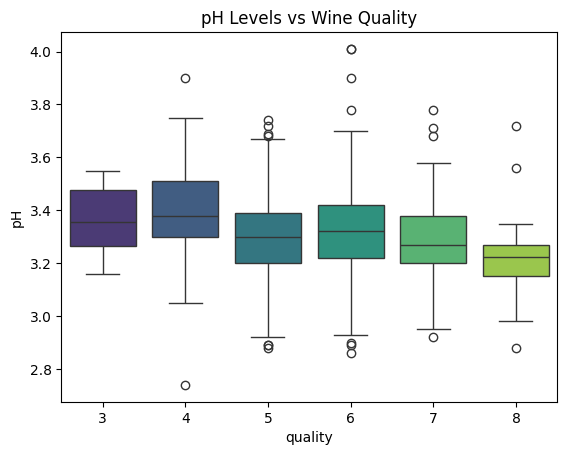

In [9]:
sns.boxplot(x='quality', y='pH', data=df, palette='viridis')
plt.title("pH Levels vs Wine Quality")